# Lab 01- A simple M/M/1 queue simulation:
Write a program which performs a simple M/M/1 queue simulation. This program requires parameters for Mean Inter Arrival time of customers, Mean Service time as well as maximum number of customers. The simulation is started with a single-server queue with a FIFO queuing discipline. For M/M/1 queue, the customer inter-arrival time and the service time are both exponentially distributed. This simulation shows Average delay in queue, Average number in queue, Server utilization, and Time simulation ended. 

Average delay in queue = 1.3785491466993331
Average number in queue = 0.626242880140126
Server utilization = 0.6471821175202579
Time simulation ended = 220.1301109229176


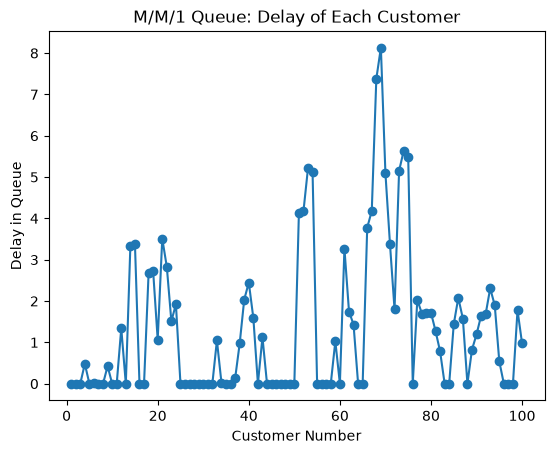

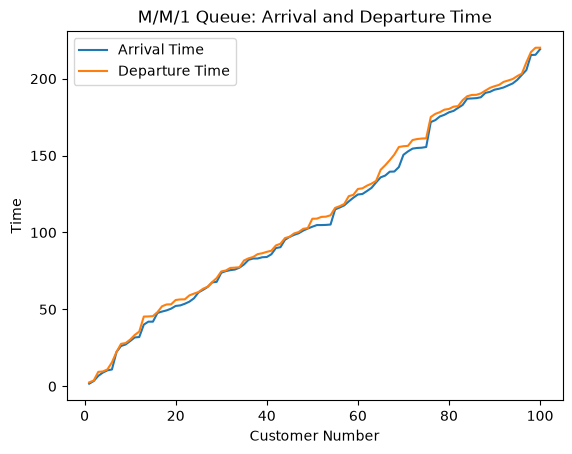

In [ ]:
import random
import matplotlib.pyplot as plt

# Same result পাওয়ার জন্য seed ব্যবহার করা হয়েছে
random.seed(10)

# Input values
mean_interarrival = 2.0                                               # Customer গড়ে 2 unit time পরপর আসে
mean_service = 1.5                                                    # একজন customer service পেতে গড়ে 1.5 unit time লাগে
max_customers = 100                                                   # মোট 100 জন customer simulate করা হবে

# Initial values
clock = 0.0                                                           # Simulation clock
server_free_time = 0.0                                                # Server কখন free হবে
total_delay = 0.0                                                     # সব customer-এর waiting time যোগ করার জন্য
busy_time = 0.0                                                       # Server মোট কত সময় busy ছিল

# Graph করার জন্য list
delays = []
arrival_times = []
departure_times = []

# 1 থেকে 100 customer পর্যন্ত loop চলবে
for customer in range(1, max_customers + 1):

    # Inter-arrival time generate করা হচ্ছে
    # অর্থাৎ একজন customer আসার পর আরেকজন customer কতক্ষণ পরে আসবে
    interarrival_time = random.expovariate(1 / mean_interarrival)

    # Service time generate করা হচ্ছে
    # অর্থাৎ একজন customer-এর service শেষ করতে কত সময় লাগবে
    service_time = random.expovariate(1 / mean_service)

    # Customer arrival time
    arrival_time = clock + interarrival_time

    # Clock update করা হচ্ছে
    clock = arrival_time

    # Server free থাকলে arrival_time-এই service start হবে
    # Server busy থাকলে server_free_time-এ service start হবে
    service_start_time = max(arrival_time, server_free_time)

    # Customer queue-তে যতক্ষণ wait করেছে
    delay = service_start_time - arrival_time

    # Customer service শেষ হওয়ার সময়
    departure_time = service_start_time + service_time

    # Server আবার কখন free হবে সেটা update
    server_free_time = departure_time

    # Total delay update
    total_delay += delay

    # Server busy time update
    busy_time += service_time

    # Graph এর জন্য data save
    delays.append(delay)
    arrival_times.append(arrival_time)
    departure_times.append(departure_time)

# Simulation শেষ হয়েছে শেষ customer departure করার সময়
simulation_end_time = server_free_time

# Average delay in queue
average_delay = total_delay / max_customers

# Arrival rate lambda
arrival_rate = max_customers / simulation_end_time

# Average number in queue
average_number_in_queue = arrival_rate * average_delay

# Server utilization
server_utilization = busy_time / simulation_end_time

# Final output
print("Average delay in queue =", average_delay)
print("Average number in queue =", average_number_in_queue)
print("Server utilization =", server_utilization)
print("Time simulation ended =", simulation_end_time)

# Graph 1: Customer delay graph
plt.plot(range(1, max_customers + 1), delays, marker="o")
plt.xlabel("Customer Number")
plt.ylabel("Delay in Queue")
plt.title("M/M/1 Queue: Delay of Each Customer")
plt.show()

# Graph 2: Arrival and departure time graph
plt.plot(range(1, max_customers + 1), arrival_times, label="Arrival Time")
plt.plot(range(1, max_customers + 1), departure_times, label="Departure Time")
plt.xlabel("Customer Number")
plt.ylabel("Time")
plt.title("M/M/1 Queue: Arrival and Departure Time")
plt.legend()
plt.show()

# Lab02
 Inventory management: Inventory management is a crucial aspect of any business that deals with physical goods. Write a program to simulate an inventory system.

Day: 1 Demand: 14 Sold: 14 Shortage: 0 Order: 0 Ending Stock: 36
Day: 2 Demand: 5 Sold: 5 Shortage: 0 Order: 0 Ending Stock: 31
Day: 3 Demand: 11 Sold: 11 Shortage: 0 Order: 40 Ending Stock: 60
Day: 4 Demand: 12 Sold: 12 Shortage: 0 Order: 0 Ending Stock: 48
Day: 5 Demand: 14 Sold: 14 Shortage: 0 Order: 0 Ending Stock: 34
Day: 6 Demand: 5 Sold: 5 Shortage: 0 Order: 0 Ending Stock: 29
Day: 7 Demand: 8 Sold: 8 Shortage: 0 Order: 0 Ending Stock: 21
Day: 8 Demand: 12 Sold: 12 Shortage: 0 Order: 40 Ending Stock: 49
Day: 9 Demand: 12 Sold: 12 Shortage: 0 Order: 0 Ending Stock: 37
Day: 10 Demand: 9 Sold: 9 Shortage: 0 Order: 0 Ending Stock: 28
Day: 11 Demand: 15 Sold: 15 Shortage: 0 Order: 40 Ending Stock: 53
Day: 12 Demand: 7 Sold: 7 Shortage: 0 Order: 0 Ending Stock: 46
Day: 13 Demand: 5 Sold: 5 Shortage: 0 Order: 0 Ending Stock: 41
Day: 14 Demand: 13 Sold: 13 Shortage: 0 Order: 0 Ending Stock: 28
Day: 15 Demand: 12 Sold: 12 Shortage: 0 Order: 40 Ending Stock: 56
Day: 16 Demand: 10 Sold: 10

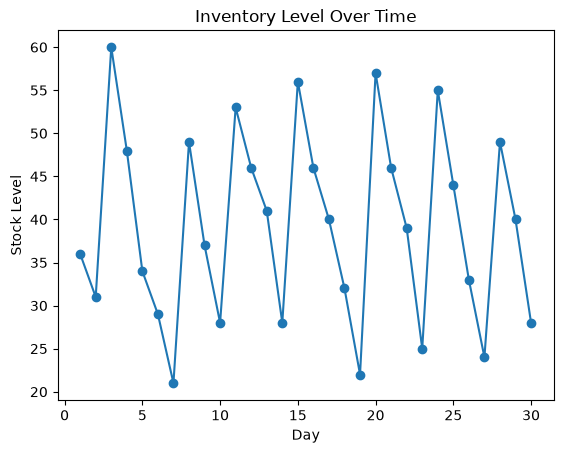

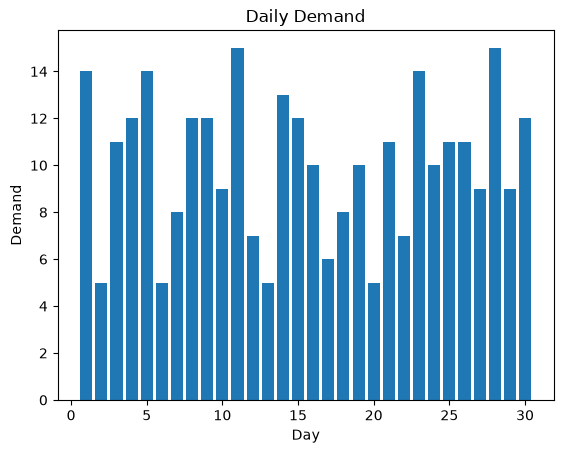

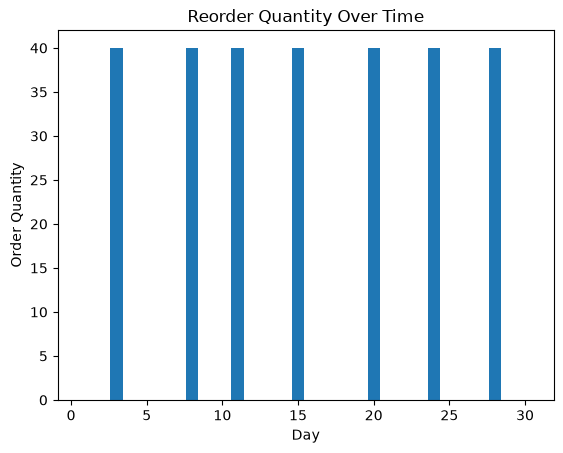

In [1]:
import random
import matplotlib.pyplot as plt

# Same random result পাওয়ার জন্য seed ব্যবহার করা হয়েছে
random.seed(10)

# Input values
days = 30                 # 30 দিনের simulation
stock = 50                # শুরুতে stock আছে 50 unit
reorder_point = 20        # stock 20 বা তার নিচে গেলে reorder হবে
order_quantity = 40       # প্রতিবার 40 unit order করা হবে

# Calculation variables
total_sales = 0           # মোট কত unit sell হয়েছে
total_shortage = 0        # মোট কত unit shortage হয়েছে
total_order = 0           # মোট কত unit order করা হয়েছে

# Graph করার জন্য list
stock_history = []
demand_history = []
shortage_history = []
order_history = []

# প্রতিদিনের simulation
for day in range(1, days + 1):

    # প্রতিদিনের random demand generate করা হচ্ছে
    demand = random.randint(5, 15)

    # যদি stock demand পূরণ করতে পারে
    if stock >= demand:
        sold = demand
        shortage = 0
        stock = stock - demand

    # যদি demand stock-এর চেয়ে বেশি হয়
    else:
        sold = stock
        shortage = demand - stock
        stock = 0

    # মোট sales এবং shortage update
    total_sales += sold
    total_shortage += shortage

    # stock reorder point-এর নিচে গেলে order হবে
    if stock <= reorder_point:
        order = order_quantity
        stock = stock + order_quantity
        total_order += order
    else:
        order = 0

    # Graph এর জন্য data save
    stock_history.append(stock)
    demand_history.append(demand)
    shortage_history.append(shortage)
    order_history.append(order)

    # প্রতিদিনের result print
    print(
        "Day:", day,
        "Demand:", demand,
        "Sold:", sold,
        "Shortage:", shortage,
        "Order:", order,
        "Ending Stock:", stock
    )

# Final output
print("\nFinal Results")
print("Total sales =", total_sales)
print("Total shortage =", total_shortage)
print("Total order quantity =", total_order)
print("Ending stock =", stock)

# Graph 1: Stock level over time
plt.plot(range(1, days + 1), stock_history, marker="o")
plt.xlabel("Day")
plt.ylabel("Stock Level")
plt.title("Inventory Level Over Time")
plt.show()

# Graph 2: Demand over time
plt.bar(range(1, days + 1), demand_history)
plt.xlabel("Day")
plt.ylabel("Demand")
plt.title("Daily Demand")
plt.show()

# Graph 3: Order quantity over time
plt.bar(range(1, days + 1), order_history)
plt.xlabel("Day")
plt.ylabel("Order Quantity")
plt.title("Reorder Quantity Over Time")
plt.show()

# Lab 03: Inventory System Simulation (Continuous Review): 
Build a simulation for an inventory system where demand is normally distributed. Implement a reorder point (s) and reorder quantity (S) policy. Track total holding costs and shortage costs over a fiscal year. 

Day: 1 Demand: 26 Shortage: 0 Shortage Cost: 0 Holding Cost: 74 Order: 0 Ending Stock: 74
Day: 2 Demand: 23 Shortage: 0 Shortage Cost: 0 Holding Cost: 51 Order: 0 Ending Stock: 51
Day: 3 Demand: 12 Shortage: 0 Shortage Cost: 0 Holding Cost: 39 Order: 0 Ending Stock: 39
Day: 4 Demand: 19 Shortage: 0 Shortage Cost: 0 Holding Cost: 20 Order: 100 Ending Stock: 120
Day: 5 Demand: 23 Shortage: 0 Shortage Cost: 0 Holding Cost: 97 Order: 0 Ending Stock: 97
Day: 6 Demand: 16 Shortage: 0 Shortage Cost: 0 Holding Cost: 81 Order: 0 Ending Stock: 81
Day: 7 Demand: 21 Shortage: 0 Shortage Cost: 0 Holding Cost: 60 Order: 0 Ending Stock: 60
Day: 8 Demand: 20 Shortage: 0 Shortage Cost: 0 Holding Cost: 40 Order: 0 Ending Stock: 40
Day: 9 Demand: 20 Shortage: 0 Shortage Cost: 0 Holding Cost: 20 Order: 100 Ending Stock: 120
Day: 10 Demand: 19 Shortage: 0 Shortage Cost: 0 Holding Cost: 101 Order: 0 Ending Stock: 101
Day: 11 Demand: 22 Shortage: 0 Shortage Cost: 0 Holding Cost: 79 Order: 0 Ending Stock: 79


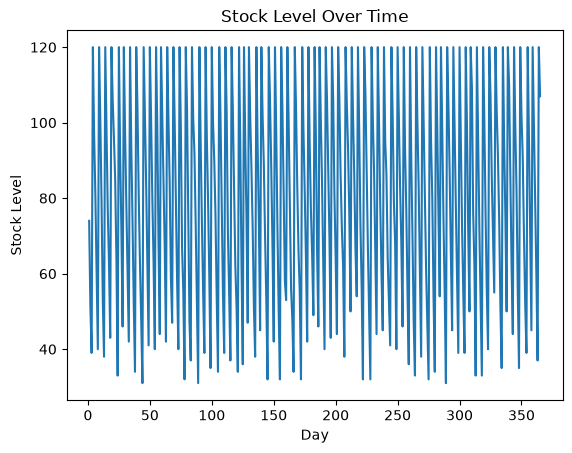

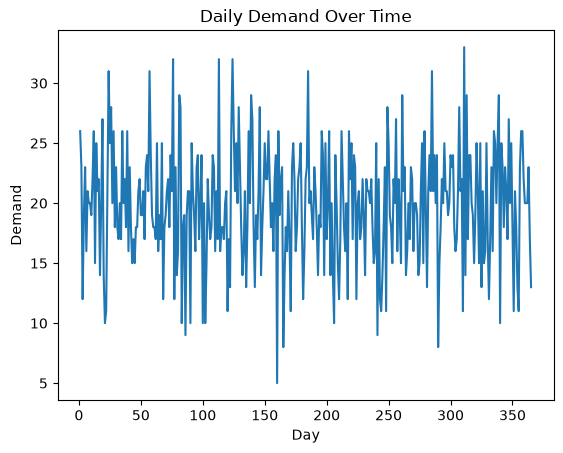

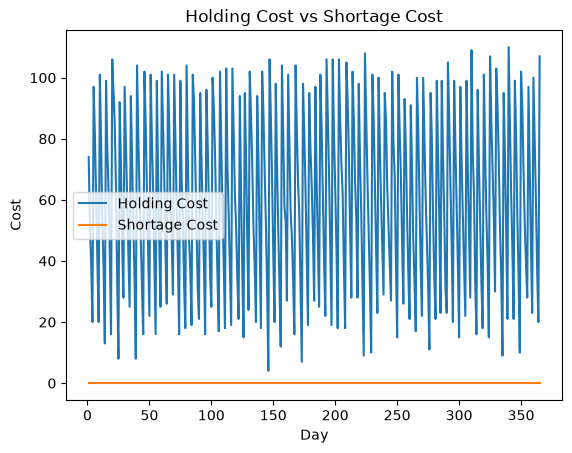

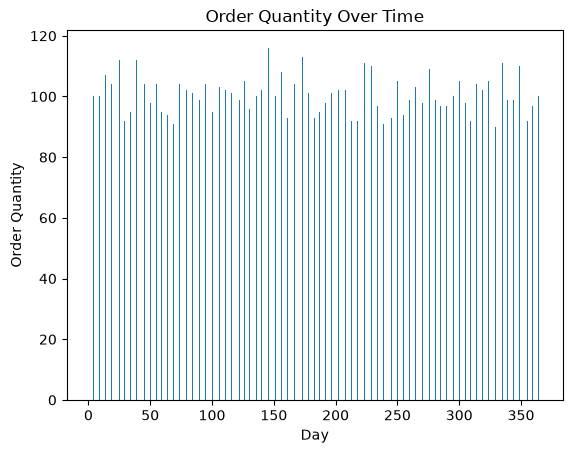

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Same random result পাওয়ার জন্য seed ব্যবহার করা হয়েছে
np.random.seed(10)

# Input values
days = 365                    # মোট simulation day
stock = 100                   # Initial inventory level

s = 30                        # Reorder point
S = 120                       # Maximum stock level after reorder

mean_demand = 20              # Average daily demand
sd_demand = 5                 # Demand-এর standard deviation

holding_cost_per_unit = 1     # প্রতি unit stock রাখার cost
shortage_cost_per_unit = 5    # প্রতি unit shortage-এর cost

# Calculation variables
total_holding_cost = 0
total_shortage_cost = 0
total_shortage = 0
total_order_quantity = 0

# Graph করার জন্য list
stock_history = []
demand_history = []
shortage_history = []
order_history = []
holding_cost_history = []
shortage_cost_history = []

# Daily simulation loop
for day in range(1, days + 1):

    # Normal distribution থেকে daily demand generate
    demand = int(np.random.normal(mean_demand, sd_demand))

    # Demand negative হলে 0 ধরা হবে
    demand = max(0, demand)

    # যদি stock demand পূরণ করতে পারে
    if stock >= demand:
        stock = stock - demand
        shortage = 0

    # যদি demand stock-এর চেয়ে বেশি হয়
    else:
        shortage = demand - stock
        stock = 0

    # Holding cost calculate
    holding_cost_today = stock * holding_cost_per_unit

    # Shortage cost calculate
    shortage_cost_today = shortage * shortage_cost_per_unit

    # Total values update
    total_holding_cost += holding_cost_today
    total_shortage_cost += shortage_cost_today
    total_shortage += shortage

    # Reorder condition
    if stock <= s:
        order_quantity = S - stock
        stock = stock + order_quantity
        total_order_quantity += order_quantity
    else:
        order_quantity = 0

    # Graph data save
    stock_history.append(stock)
    demand_history.append(demand)
    shortage_history.append(shortage)
    order_history.append(order_quantity)
    holding_cost_history.append(holding_cost_today)
    shortage_cost_history.append(shortage_cost_today)

    # Daily output
    print(
        "Day:", day,
        "Demand:", demand,
        "Shortage:", shortage,
        "Shortage Cost:", shortage_cost_today,
        "Holding Cost:", holding_cost_today,
        "Order:", order_quantity,
        "Ending Stock:", stock
    )

# Final total cost
total_cost = total_holding_cost + total_shortage_cost

# Final output
print("\nFinal Results")
print("Total holding cost =", total_holding_cost)
print("Total shortage =", total_shortage)
print("Total shortage cost =", total_shortage_cost)
print("Total order quantity =", total_order_quantity)
print("Total cost =", total_cost)
print("Ending stock =", stock)

# Graph 1: Stock level over time
plt.plot(range(1, days + 1), stock_history)
plt.xlabel("Day")
plt.ylabel("Stock Level")
plt.title("Stock Level Over Time")
plt.show()

# Graph 2: Daily demand
plt.plot(range(1, days + 1), demand_history)
plt.xlabel("Day")
plt.ylabel("Demand")
plt.title("Daily Demand Over Time")
plt.show()

# Graph 3: Holding cost vs shortage cost
plt.plot(range(1, days + 1), holding_cost_history, label="Holding Cost")
plt.plot(range(1, days + 1), shortage_cost_history, label="Shortage Cost")
plt.xlabel("Day")
plt.ylabel("Cost")
plt.title("Holding Cost vs Shortage Cost")
plt.legend()
plt.show()

# Graph 4: Order quantity
plt.bar(range(1, days + 1), order_history)
plt.xlabel("Day")
plt.ylabel("Order Quantity")
plt.title("Order Quantity Over Time")
plt.show()

# Lab 04: Bernoulli data distribution:
A Manufacturing and Reliability Lab is testing a newly produced batch of microchips. Each chip undergoes a strict operational test and either works perfectly (Success = 1) or fails (Failure = 0). Historical data shows that the probability of any given chip passing this test is p = 0.85. This lab problem models a Bernoulli distribution using a Quality-Control Test. It guides students through defining a binary outcome (success/failure). State the values of X and what they represent. Calculating probabilities, and finding expected metrics. Calculate the probability of a defect, P(X=0). Find the mean: Calculate the expected value, E[X]. Find the spread: Calculate the variance, Var(X).

Probability of Pass, P(X=1) = 0.85
Probability of Fail/Defect, P(X=0) = 0.15000000000000002
Mean = 0.85
Variance = 0.1275


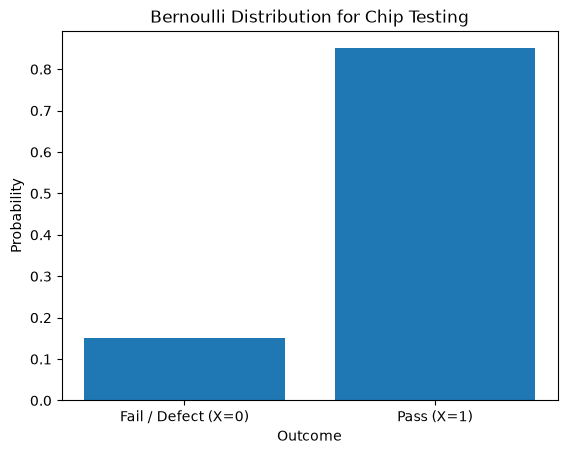

In [31]:
import matplotlib.pyplot as plt

# Probability of success/pass
p = 0.85

# Probability of failure/defect
q = 1 - p

# Bernoulli distribution mean
mean = p

# Bernoulli distribution variance
variance = p * q

# Output
print("Probability of Pass, P(X=1) =", p)
print("Probability of Fail/Defect, P(X=0) =", q)
print("Mean =", mean)
print("Variance =", variance)

# Graphical view
# X = 0 means fail, X = 1 means pass
outcomes = ["Fail / Defect (X=0)", "Pass (X=1)"]
probabilities = [q, p]

plt.bar(outcomes, probabilities)
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution for Chip Testing")
plt.show()

# Lab 05: Network Packet Delivery:
Scenario- A network router transmits data packets in batches. Each individual packet has a success probability of p = 0.90 of reaching its destination. A single batch consists of n = 15 independent packets. Example Data: A simulation of 5 separate batches reveals the number of successfully delivered packets per batch: 14, 13, 15, 12, 14. Tasks: Identify parameters: Define the values for n, p, and q (failure probability). Exact Probability: Calculate the probability that exactly 13 packets arrive safely in a batch. Expected Value & Variance: Compute the theoretical mean µ and variance σ for the batch. Data Verification: Calculate the average number of successful packets from the example data and compare it to the theoretical mean.

Probability of exactly 13 packets arrive = 0.26689591197454493
Mean = 13.5
Variance = 1.3499999999999996
Sample average = 13.6


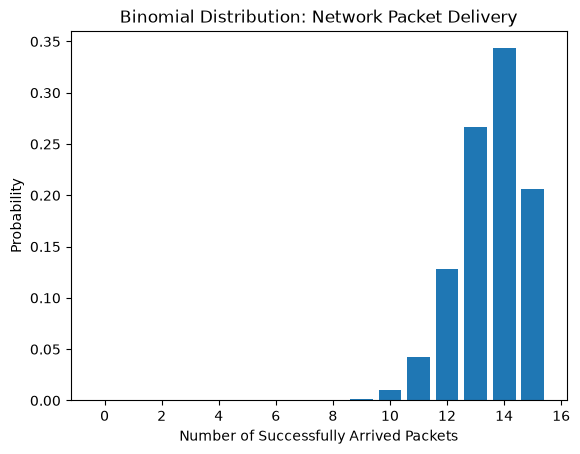

In [ ]:
import math
import matplotlib.pyplot as plt

# Total number of packets sent
n = 15

# Probability that one packet successfully arrives
p = 0.90

# Probability that one packet fails
q = 1 - p

# We need probability of exactly 13 successful packets
x = 13

# Sample observed data
data = [14, 13, 15, 12, 14]

# Binomial probability for exactly 13 packets
probability_13 = math.comb(n, x) * (p ** x) * (q ** (n - x))    #

# Mean of binomial distribution
mean = n * p

# Variance of binomial distribution
variance = n * p * q

# Sample average from observed data
sample_average = sum(data) / len(data)

# Output
print("Probability of exactly 13 packets arrive =", probability_13)
print("Mean =", mean)
print("Variance =", variance)
print("Sample average =", sample_average)

# Graph data
x_values = list(range(0, n + 1))
probabilities = []

# Probability for 0 to 15 successful packets
for k in x_values:
    prob = math.comb(n, k) * (p ** k) * (q ** (n - k))
    probabilities.append(prob)

# Graphical view
plt.bar(x_values, probabilities)
plt.xlabel("Number of Successfully Arrived Packets")
plt.ylabel("Probability")
plt.title("Binomial Distribution: Network Packet Delivery")
plt.show()

# Lab 06: Poisson Distribution: 
A customer care center receives 5 calls per hour. Compute the probability of attending zero calls, one call, two call, ….., ten calls per hour. Simulate the probability mass function respect to the number of receiving call. Show the probability mass function graphs considering 10 and 15 calls per hour.

P(X=0) = 0.0067
P(X=1) = 0.0337
P(X=2) = 0.0842
P(X=3) = 0.1404
P(X=4) = 0.1755
P(X=5) = 0.1755
P(X=6) = 0.1462
P(X=7) = 0.1044
P(X=8) = 0.0653
P(X=9) = 0.0363
P(X=10) = 0.0181


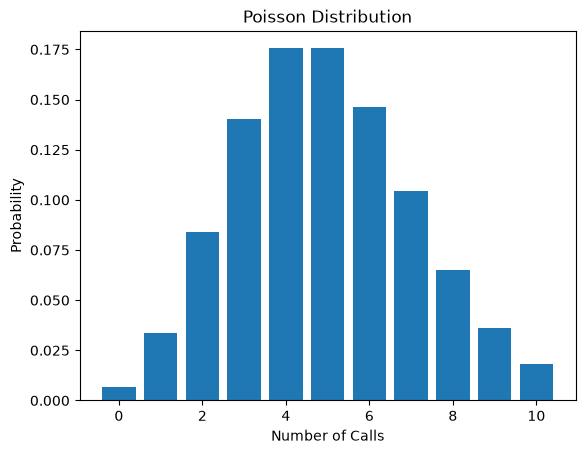

In [ ]:
import math
import matplotlib.pyplot as plt

# Average number of calls per hour ...average rate
lam = 5

# We will calculate probability from 0 to 10 calls
x_values = list(range(0, 11))

# Probability values রাখার জন্য list
probabilities = []

# Mean and variance for Poisson distribution
mean = lam
variance = lam

# Probability calculation
for k in x_values:

    # Poisson probability formula:
    # P(X=k) = e^(-lambda) * lambda^k / k!
    probability = (math.exp(-lam) * (lam ** k)) / math.factorial(k)

    # Probability list-এ save
    probabilities.append(probability)

    # Each probability print
    print("P(X =", k, ") =", probability)

# Final output
print("\nMean =", mean)
print("Variance =", variance)

# Graphical view
plt.bar(x_values, probabilities)
plt.xlabel("Number of Calls per Hour")
plt.ylabel("Probability")
plt.title("Poisson Distribution: Calls per Hour")
plt.show()

# Lab 07: Normal Distribution: 
To Show unimodal and multimodal density curves of normal distribution. To generate random sample with sample size 200, which follows a normal distribution with mean 100 and standard deviation 20. The distribution of diastolic blood pressure for men is normally distributed with a mean of about 80 and a standard deviation of 20. A histogram of the distribution of blood pressures for all mean displays a normal distribution with bell shape.

Random sample mean = 101.48613846633367
Random sample standard deviation = 19.524868221195696
Blood pressure sample mean = 80.55685365869508
Blood pressure sample standard deviation = 18.496676332084284


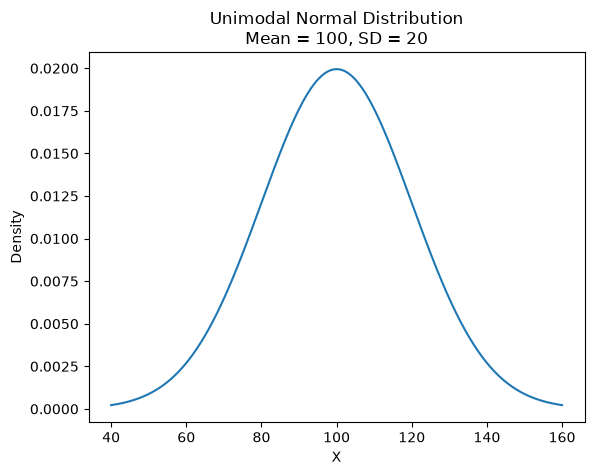

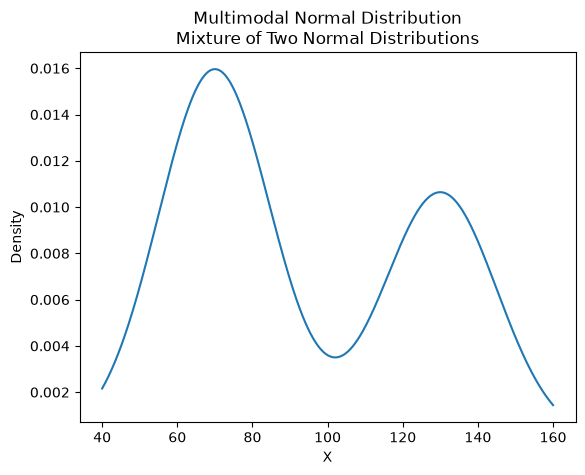

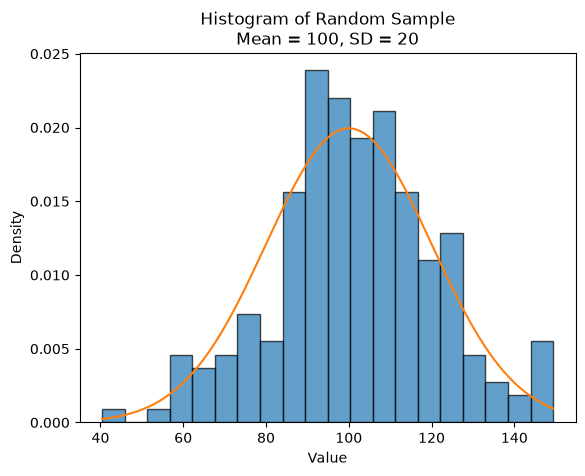

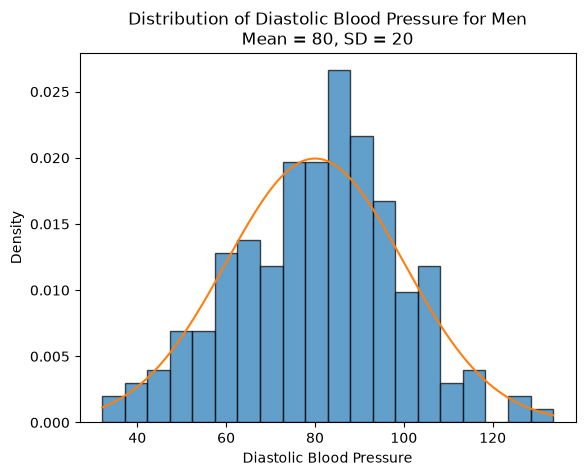

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Same random result পাওয়ার জন্য seed ব্যবহার করা হয়েছে
np.random.seed(10)

# ----------------------------------------------------
# Part 1: Unimodal Normal Distribution
# ----------------------------------------------------

# x-axis values তৈরি করা হচ্ছে
x = np.linspace(40, 160, 1000)

# Unimodal normal distribution parameters
mean1 = 100
sd1 = 20

# Normal probability density function
y1 = norm.pdf(x, mean1, sd1)

# ----------------------------------------------------
# Part 2: Multimodal Normal Distribution
# ----------------------------------------------------

# Multimodal তৈরি করার জন্য দুইটা normal distribution mix করা হচ্ছে
mean2_1 = 70
sd2_1 = 15

mean2_2 = 130
sd2_2 = 15

# Weight মানে কোন distribution কতটা contribution দেবে
weight1 = 0.6
weight2 = 0.4

# Mixture of two normal distributions
y2 = weight1 * norm.pdf(x, mean2_1, sd2_1) + weight2 * norm.pdf(x, mean2_2, sd2_2)

# ----------------------------------------------------
# Part 3: Random Sample Generation
# ----------------------------------------------------

# Mean 100 এবং SD 20 সহ 200 sample generate করা হচ্ছে
sample = np.random.normal(100, 20, 200)

# ----------------------------------------------------
# Part 4: Diastolic Blood Pressure Sample
# ----------------------------------------------------

# Men's diastolic blood pressure normally distributed
# Mean = 80, SD = 20, Sample size = 200
bp_sample = np.random.normal(80, 20, 200)

# Sample result print
print("Random sample mean =", np.mean(sample))
print("Random sample standard deviation =", np.std(sample))

print("Blood pressure sample mean =", np.mean(bp_sample))
print("Blood pressure sample standard deviation =", np.std(bp_sample))

# ----------------------------------------------------
# Graph 1: Unimodal Normal Distribution
# ----------------------------------------------------

plt.plot(x, y1)
plt.xlabel("X")
plt.ylabel("Density")
plt.title("Unimodal Normal Distribution\nMean = 100, SD = 20")
plt.show()

# ----------------------------------------------------
# Graph 2: Multimodal Normal Distribution
# ----------------------------------------------------

plt.plot(x, y2)
plt.xlabel("X")
plt.ylabel("Density")
plt.title("Multimodal Normal Distribution\nMixture of Two Normal Distributions")
plt.show()

# ----------------------------------------------------
# Graph 3: Histogram of Random Sample
# ----------------------------------------------------

plt.hist(sample, bins=20, density=True, edgecolor="black", alpha=0.7)

# Normal curve overlay
x_sample = np.linspace(min(sample), max(sample), 1000)
y_sample = norm.pdf(x_sample, 100, 20)

plt.plot(x_sample, y_sample)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of Random Sample\nMean = 100, SD = 20")
plt.show()

# ----------------------------------------------------
# Graph 4: Histogram of Diastolic Blood Pressure
# ----------------------------------------------------

plt.hist(bp_sample, bins=20, density=True, edgecolor="black", alpha=0.7)

# Blood pressure normal curve overlay
x_bp = np.linspace(min(bp_sample), max(bp_sample), 1000)
y_bp = norm.pdf(x_bp, 80, 20)

plt.plot(x_bp, y_bp)
plt.xlabel("Diastolic Blood Pressure")
plt.ylabel("Density")
plt.title("Distribution of Diastolic Blood Pressure for Men\nMean = 80, SD = 20")
plt.show()

# Lab 08: Exponential Distribution: 
There were few waves in COVID-19 pandemic. Let a wave occurs every 100 days in Bangladesh, on average. After a wave occurs, find the probability using Exponential distribution that it will take more than 120 days for the next wave to occur. Simulate several Exponential distribution using rate parameters 0.5, 1.0, 2.0, and 4.0. 

Mean time between waves = 100 days
Rate parameter lambda = 0.01
P(next wave takes more than 120 days) = 0.30119421191220214


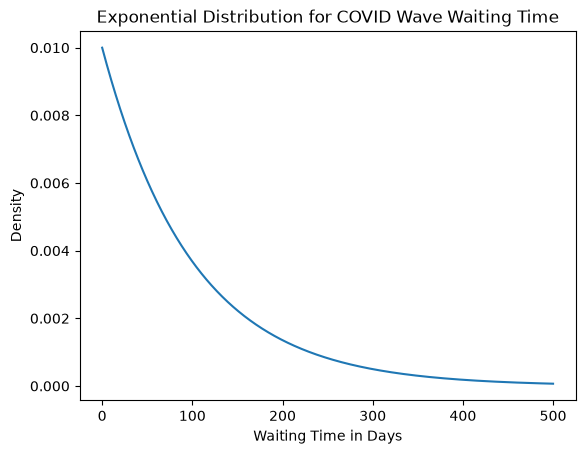

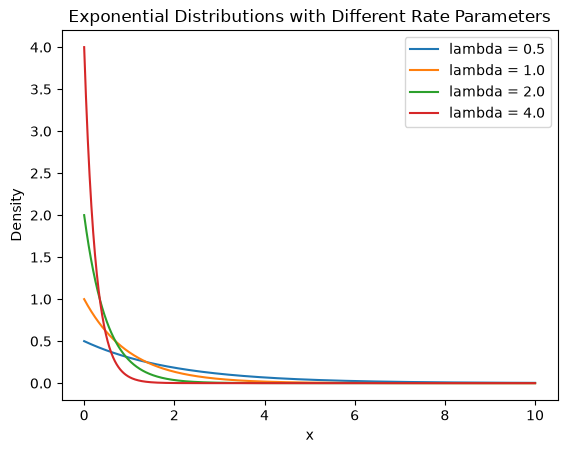

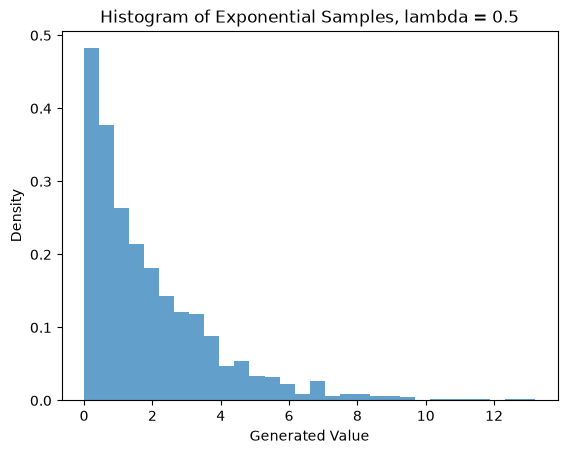

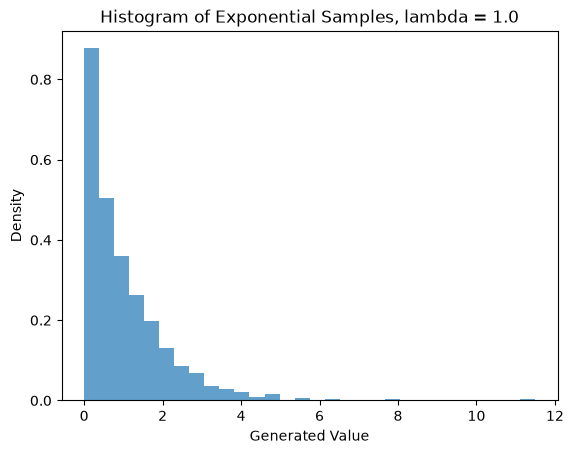

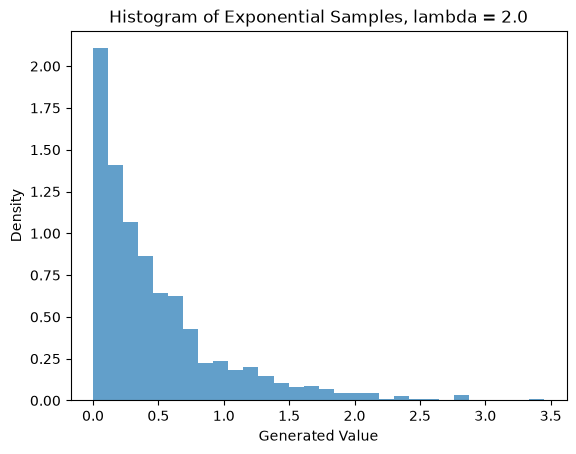

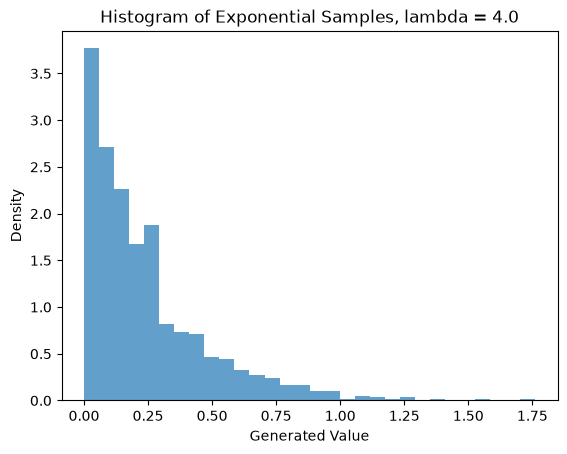

In [34]:
import math
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Part 1: Probability that next wave takes more than 120 days
# --------------------------------------------------

# Average time between two COVID waves
mean_days = 100

# Rate parameter lambda = 1 / mean
lam = 1 / mean_days

# We need P(X > 120)
x_value = 120

# Exponential survival probability formula
# P(X > x) = e^(-lambda * x)
probability_more_than_120 = math.exp(-lam * x_value)

# Output
print("Mean time between waves =", mean_days, "days")
print("Rate parameter lambda =", lam)
print("P(next wave takes more than 120 days) =", probability_more_than_120)

# --------------------------------------------------
# Part 2: Exponential density curve for COVID wave waiting time
# --------------------------------------------------

# x-axis values from 0 to 500 days
x = np.linspace(0, 500, 1000)

# Exponential probability density function
y = lam * np.exp(-lam * x)

# Graph 1: COVID wave waiting time distribution
plt.plot(x, y)
plt.xlabel("Waiting Time in Days")
plt.ylabel("Density")
plt.title("Exponential Distribution for COVID Wave Waiting Time")
plt.show()

# --------------------------------------------------
# Part 3: Simulate several exponential distributions
# --------------------------------------------------

# Different rate parameters
rate_parameters = [0.5, 1.0, 2.0, 4.0]

# x-axis for simulated density curves
x2 = np.linspace(0, 10, 1000)

# Plot exponential curves for different lambda values
for rate in rate_parameters:

    # Exponential PDF formula
    y2 = rate * np.exp(-rate * x2)

    # Plot each exponential curve
    plt.plot(x2, y2, label="lambda = " + str(rate))

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Exponential Distributions with Different Rate Parameters")
plt.legend()
plt.show()

# --------------------------------------------------
# Part 4: Generate random samples for each rate parameter
# --------------------------------------------------

np.random.seed(10)

sample_size = 1000

for rate in rate_parameters:

    # Exponential random sample generate
    # numpy scale = 1 / lambda
    samples = np.random.exponential(scale=1 / rate, size=sample_size)

    # Histogram for each rate
    plt.hist(samples, bins=30, density=True, alpha=0.7)

    plt.xlabel("Generated Value")
    plt.ylabel("Density")
    plt.title("Histogram of Exponential Samples, lambda = " + str(rate))
    plt.show()

# Lab 09: Empirical Input Modeling: 
Given a raw dataset of customer arrival times at a call center, fit the data to theoretical distributions (e.g., Normal, Weibull, or Lognormal) using Maximum Likelihood Estimation (MLE). Validate the fit with Q-Q plots.

Normal Distribution Parameters
Mean = 3.646666666666667
Standard Deviation = 1.184267237108622

Weibull Distribution Parameters
Shape = 1.7914960269522777
Location = 1.5606613054650775
Scale = 2.3398730366890512

Lognormal Distribution Parameters
Shape = 0.26632693978495847
Location = -0.8351560736693123
Scale = 4.327311741995211


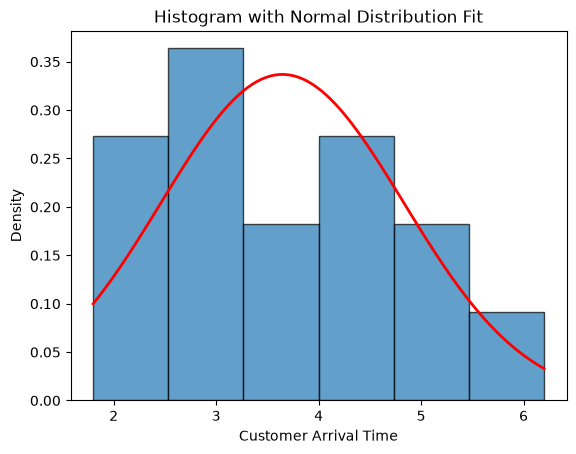

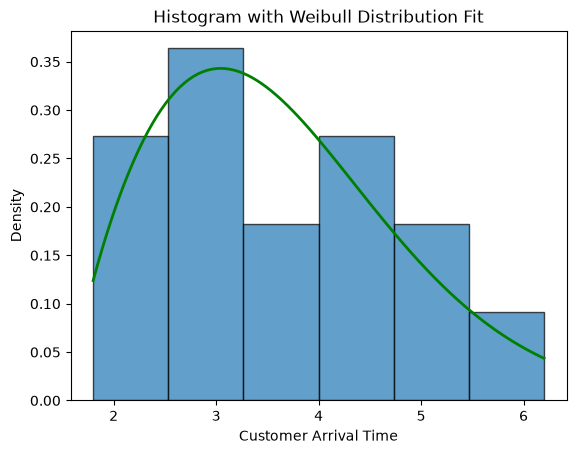

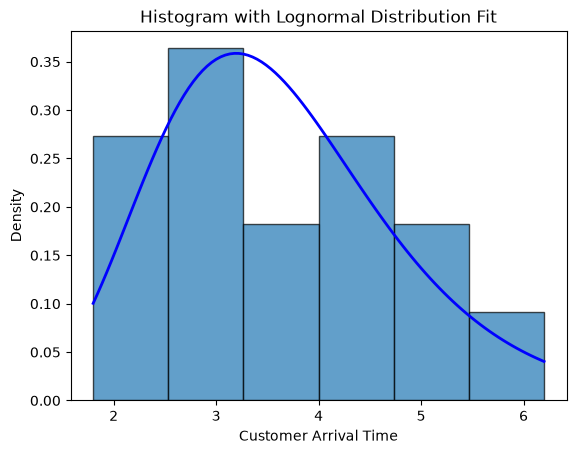

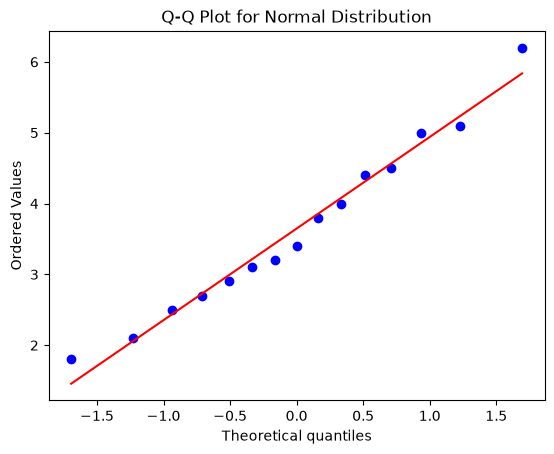

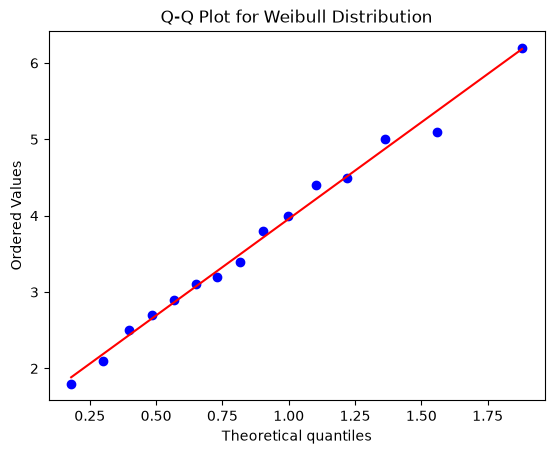

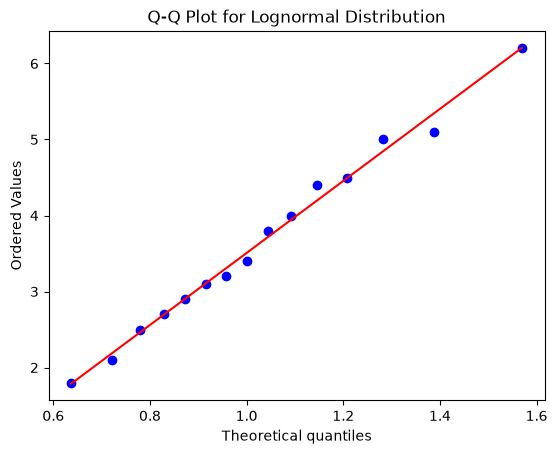

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --------------------------------------------------
# Raw customer arrival time dataset
# --------------------------------------------------

data = np.array([
    2.1, 3.4, 1.8, 4.5, 3.2,
    5.1, 2.7, 4.0, 3.8, 2.9,
    6.2, 3.1, 4.4, 2.5, 5.0
])

# --------------------------------------------------
# Maximum Likelihood Estimation (MLE)   a statistical method used to determine the parameters of a probability distribution that best explain the observed data
# --------------------------------------------------

# Normal distribution parameters
normal_mu, normal_sigma = stats.norm.fit(data)

# Weibull distribution parameters
weibull_shape, weibull_loc, weibull_scale = stats.weibull_min.fit(data)

# Lognormal distribution parameters
log_shape, log_loc, log_scale = stats.lognorm.fit(data)

# Output
print("Normal Distribution Parameters")
print("Mean =", normal_mu)
print("Standard Deviation =", normal_sigma)

print("\nWeibull Distribution Parameters")
print("Shape =", weibull_shape)
print("Location =", weibull_loc)
print("Scale =", weibull_scale)

print("\nLognormal Distribution Parameters")
print("Shape =", log_shape)
print("Location =", log_loc)
print("Scale =", log_scale)

# --------------------------------------------------
# Histogram with Normal Distribution
# --------------------------------------------------

plt.hist(data, bins=6, density=True, edgecolor="black", alpha=0.7)

# Normal PDF
x = np.linspace(min(data), max(data), 100)
y = stats.norm.pdf(x, normal_mu, normal_sigma)

plt.plot(x, y, color="red", linewidth=2)

plt.xlabel("Customer Arrival Time")
plt.ylabel("Density")
plt.title("Histogram with Normal Distribution Fit")
plt.show()

# --------------------------------------------------
# Histogram with Weibull Distribution
# --------------------------------------------------

plt.hist(data, bins=6, density=True, edgecolor="black", alpha=0.7)

y = stats.weibull_min.pdf(x,
                          weibull_shape,
                          weibull_loc,
                          weibull_scale)

plt.plot(x, y, color="green", linewidth=2)

plt.xlabel("Customer Arrival Time")
plt.ylabel("Density")
plt.title("Histogram with Weibull Distribution Fit")
plt.show()

# --------------------------------------------------
# Histogram with Lognormal Distribution
# --------------------------------------------------

plt.hist(data, bins=6, density=True, edgecolor="black", alpha=0.7)

y = stats.lognorm.pdf(x,
                      log_shape,
                      log_loc,
                      log_scale)

plt.plot(x, y, color="blue", linewidth=2)

plt.xlabel("Customer Arrival Time")
plt.ylabel("Density")
plt.title("Histogram with Lognormal Distribution Fit")
plt.show()

# --------------------------------------------------
# Q-Q Plot for Normal Distribution
# --------------------------------------------------

stats.probplot(data,
               dist="norm",
               plot=plt)

plt.title("Q-Q Plot for Normal Distribution")
plt.show()

# --------------------------------------------------
# Q-Q Plot for Weibull Distribution
# --------------------------------------------------

stats.probplot(data,
               dist=stats.weibull_min,
               sparams=(weibull_shape,),
               plot=plt)

plt.title("Q-Q Plot for Weibull Distribution")
plt.show()

# --------------------------------------------------
# Q-Q Plot for Lognormal Distribution
# --------------------------------------------------

stats.probplot(data,
               dist=stats.lognorm,
               sparams=(log_shape,),
               plot=plt)

plt.title("Q-Q Plot for Lognormal Distribution")
plt.show()

# Lab 10: Machine Breakdown and Maintenance: 
Simulate a manufacturing workshop containing 5 identical machines. The time between breakdowns is exponentially distributed, and repair times follow a Weibull distribution. Calculate machine downtime and overall system throughput.

Machine 1
Breakdown count = 11
Downtime = 83.4753747128897
Uptime = 916.5246252871103
Throughput = 916.5246252871103
------------------------------
Machine 2
Breakdown count = 6
Downtime = 60.59972104247981
Uptime = 939.4002789575202
Throughput = 939.4002789575202
------------------------------
Machine 3
Breakdown count = 6
Downtime = 52.47382492648956
Uptime = 947.5261750735104
Throughput = 947.5261750735104
------------------------------
Machine 4
Breakdown count = 8
Downtime = 76.68796850056698
Uptime = 923.312031499433
Throughput = 923.312031499433
------------------------------
Machine 5
Breakdown count = 13
Downtime = 108.82951103525936
Uptime = 891.1704889647407
Throughput = 891.1704889647407
------------------------------

Final Results
Total system downtime = 382.06640021768544
Average machine downtime = 76.41328004353709
Total system uptime = 4617.933599782315
Overall system throughput = 4617.933599782315


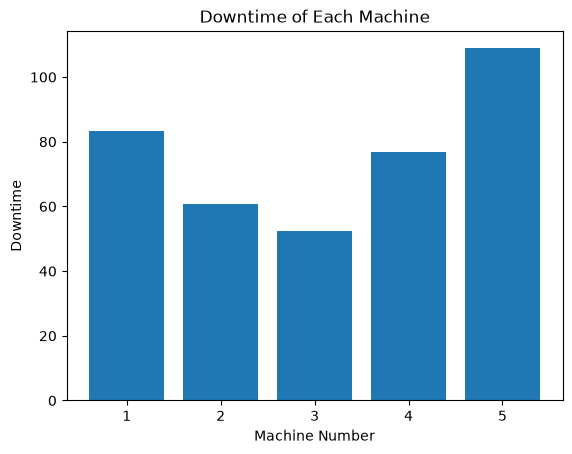

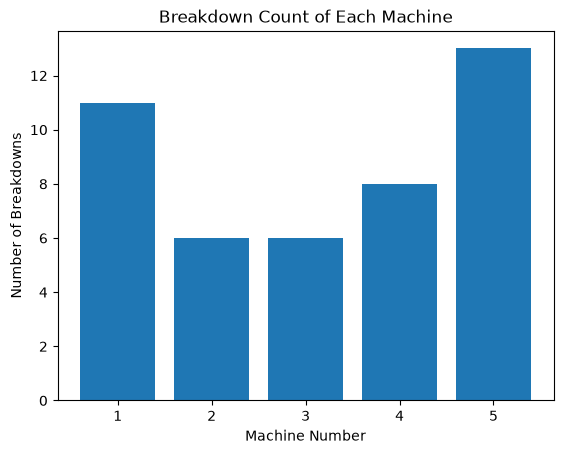

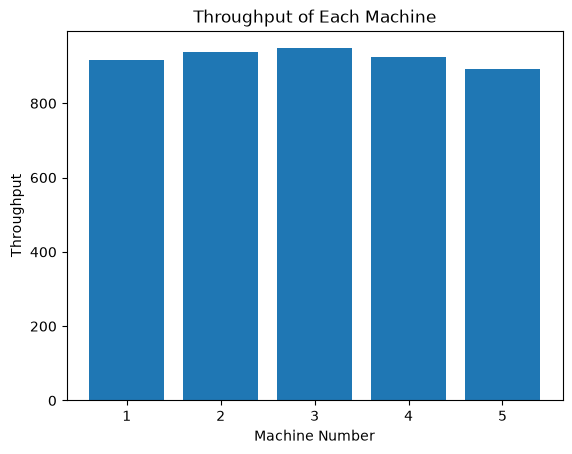

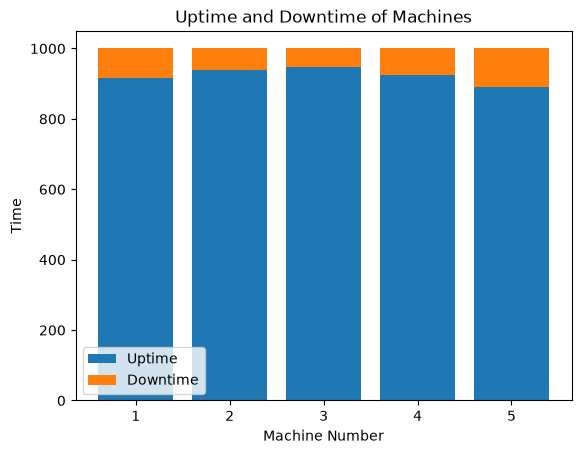

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Same random result পাওয়ার জন্য seed
random.seed(10)
np.random.seed(10)

# --------------------------------------------------
# Input values
# --------------------------------------------------

num_machines = 5               # মোট 5টি machine
simulation_time = 1000         # মোট simulation time

mean_breakdown_time = 100      # Average time between breakdowns

weibull_shape = 2              # Weibull shape parameter
weibull_scale = 10             # Weibull scale parameter

production_rate = 1            # প্রতি unit time-এ এক machine 1 unit produce করে

# --------------------------------------------------
# Calculation variables
# --------------------------------------------------

machine_downtimes = []         # প্রতিটি machine-এর downtime রাখবে
machine_uptimes = []           # প্রতিটি machine-এর uptime রাখবে
machine_throughputs = []       # প্রতিটি machine-এর throughput রাখবে
breakdown_counts = []          # প্রতিটি machine কতবার breakdown হয়েছে

# --------------------------------------------------
# Simulation for each machine
# --------------------------------------------------

for machine in range(1, num_machines + 1):

    time = 0                   # প্রতিটি machine-এর নিজস্ব clock
    downtime = 0               # machine কত সময় বন্ধ ছিল
    breakdown_count = 0        # breakdown সংখ্যা

    # যতক্ষণ simulation time শেষ না হয়
    while time < simulation_time:

        # Exponential distribution থেকে next breakdown time
        time_to_breakdown = random.expovariate(1 / mean_breakdown_time)

        # Machine breakdown হওয়ার সময় পর্যন্ত কাজ করে
        time = time + time_to_breakdown

        # যদি simulation time শেষ হয়ে যায়, loop stop
        if time >= simulation_time:
            break

        # Weibull distribution থেকে repair time generate
        repair_time = weibull_scale * np.random.weibull(weibull_shape)

        # Repair time মানেই downtime
        downtime = downtime + repair_time

        # Repair time যোগ করে machine আবার চালু হবে
        time = time + repair_time

        # Breakdown count update
        breakdown_count = breakdown_count + 1

    # Uptime = total simulation time - downtime
    uptime = simulation_time - downtime

    # Throughput = uptime × production rate
    throughput = uptime * production_rate

    # Data save
    machine_downtimes.append(downtime)
    machine_uptimes.append(uptime)
    machine_throughputs.append(throughput)
    breakdown_counts.append(breakdown_count)

    # Individual machine output
    print("Machine", machine)
    print("Breakdown count =", breakdown_count)
    print("Downtime =", downtime)
    print("Uptime =", uptime)
    print("Throughput =", throughput)
    print("------------------------------")

# --------------------------------------------------
# Final results
# --------------------------------------------------

total_downtime = sum(machine_downtimes)
total_uptime = sum(machine_uptimes)
overall_throughput = sum(machine_throughputs)

average_downtime = total_downtime / num_machines

print("\nFinal Results")
print("Total system downtime =", total_downtime)
print("Average machine downtime =", average_downtime)
print("Total system uptime =", total_uptime)
print("Overall system throughput =", overall_throughput)

# --------------------------------------------------
# Graph 1: Machine downtime
# --------------------------------------------------

plt.bar(range(1, num_machines + 1), machine_downtimes)
plt.xlabel("Machine Number")
plt.ylabel("Downtime")
plt.title("Downtime of Each Machine")
plt.show()

# --------------------------------------------------
# Graph 2: Breakdown count
# --------------------------------------------------

plt.bar(range(1, num_machines + 1), breakdown_counts)
plt.xlabel("Machine Number")
plt.ylabel("Number of Breakdowns")
plt.title("Breakdown Count of Each Machine")
plt.show()

# --------------------------------------------------
# Graph 3: Machine throughput
# --------------------------------------------------

plt.bar(range(1, num_machines + 1), machine_throughputs)
plt.xlabel("Machine Number")
plt.ylabel("Throughput")
plt.title("Throughput of Each Machine")
plt.show()

# --------------------------------------------------
# Graph 4: Uptime vs Downtime
# --------------------------------------------------

machines = np.arange(1, num_machines + 1)

plt.bar(machines, machine_uptimes, label="Uptime")
plt.bar(machines, machine_downtimes, bottom=machine_uptimes, label="Downtime")

plt.xlabel("Machine Number")
plt.ylabel("Time")
plt.title("Uptime and Downtime of Machines")
plt.legend()
plt.show()

# Lab 11: Linear Congruential Generator (LCG): 
LCG is considered one of the basic yet best methods to generate Pseudo-Random Numbers. Write a program which generates the random number using the LCG.

[0.375, 0.0625, 0.5, 0.6875, 0.625, 0.3125, 0.75, 0.9375, 0.875, 0.5625, 0.0, 0.1875, 0.125, 0.8125, 0.25, 0.4375, 0.375, 0.0625, 0.5, 0.6875]


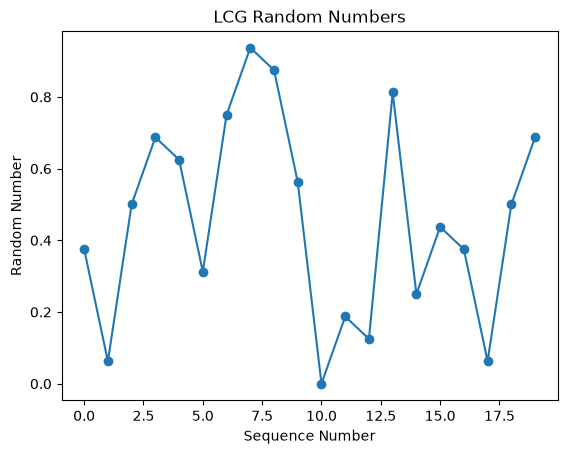

In [ ]:
import matplotlib.pyplot as plt

seed = 7
a = 5  #multiplier
c = 3  #increment
m = 16 #modulus
n = 20 # number of pseudo-random numbers to generate

x = seed
numbers = []

for i in range(n):
    x = (a * x + c) % m      # Xn+1 = (aXn + c) mod m
    random_number = x / m
    numbers.append(random_number)

print(numbers)

# Graphical view
plt.plot(numbers, marker="o")
plt.xlabel("Sequence Number")
plt.ylabel("Random Number")
plt.title("LCG Random Numbers")
plt.show()

# Lab 12: Random variates using the inverse transform function: 
There are several general approaches to generating univariate Random Variable from the distribution function. Write a program which generates the desired number of random variates using the inverse transform function.

First 10 random variates: [0.73771722 0.01048515 0.50208065 0.69076065 0.34508283 0.12731495
 0.11036253 0.71466505 0.09262944 0.04624398]


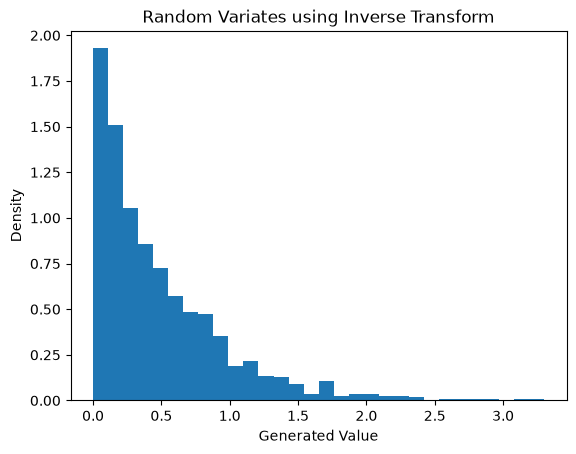

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

lam = 2   # rate parameter λ = 2
n = 1000

u = np.random.rand(n)   # Uniform random number generate  [ U∼Uniform(0,1) ]   U=1−e^−λx

# Inverse transform formula for exponential distribution
x = -np.log(1 - u) / lam

print("First 10 random variates:", x[:10])

# Graphical view
plt.hist(x, bins=30, density=True)
plt.xlabel("Generated Value")
plt.ylabel("Density")
plt.title("Random Variates using Inverse Transform")
plt.show()

# Lab 13: 
Generate 5,000 exponentially distributed random numbers using the Inverse Transform technique. Plot a histogram of the resulting numbers and overlay the theoretical exponential probability density function.

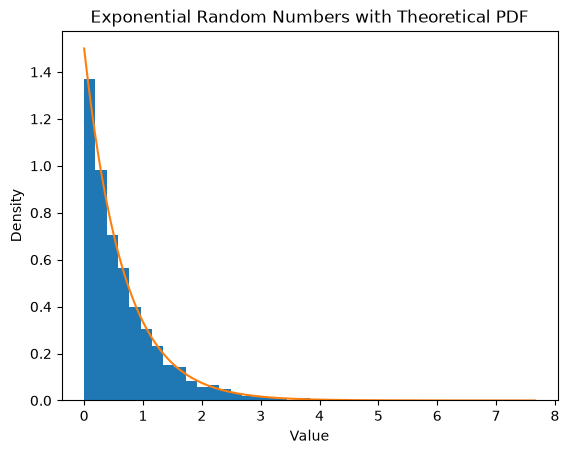

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

lam = 1.5  # rate parameter λ = 1.5
n = 5000

u = np.random.rand(n)  # Uniform random number generate  [ U∼Uniform(0,1) ]   U=1−e^−λx
data = -np.log(1 - u) / lam

x = np.linspace(0, max(data), 200)
pdf = lam * np.exp(-lam * x)

# Graphical view
plt.hist(data, bins=40, density=True)
plt.plot(x, pdf)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Exponential Random Numbers with Theoretical PDF")  # probability density function
plt.show()

# Lab 14: Debugging and Traceability (Verification): 
Write a trace program to step through a discrete-event model and log system states, ensuring it adheres exactly to the logical model rules.

Discrete-event simulation-এ system time continuous ভাবে change হয় না।
বরং event ঘটলে system state change হয়।
Arrival
Departure

Event: 1 Time: 4 Type: Arrival    Queue: 1
Event: 2 Time: 9 Type: Departure    Queue: 0
Event: 3 Time: 11 Type: Arrival    Queue: 1
Event: 4 Time: 15 Type: Departure    Queue: 0
Event: 5 Time: 17 Type: Departure    Queue: 0
Event: 6 Time: 22 Type: Arrival    Queue: 1
Event: 7 Time: 25 Type: Departure    Queue: 0
Event: 8 Time: 27 Type: Arrival    Queue: 1
Event: 9 Time: 28 Type: Departure    Queue: 0
Event: 10 Time: 30 Type: Departure    Queue: 0
Event: 11 Time: 34 Type: Departure    Queue: 0
Event: 12 Time: 37 Type: Departure    Queue: 0
Event: 13 Time: 41 Type: Departure    Queue: 0
Event: 14 Time: 44 Type: Arrival    Queue: 1
Event: 15 Time: 46 Type: Departure    Queue: 0
Event: 16 Time: 48 Type: Departure    Queue: 0
Event: 17 Time: 53 Type: Departure    Queue: 0
Event: 18 Time: 54 Type: Departure    Queue: 0
Event: 19 Time: 56 Type: Arrival    Queue: 1
Event: 20 Time: 58 Type: Arrival    Queue: 2


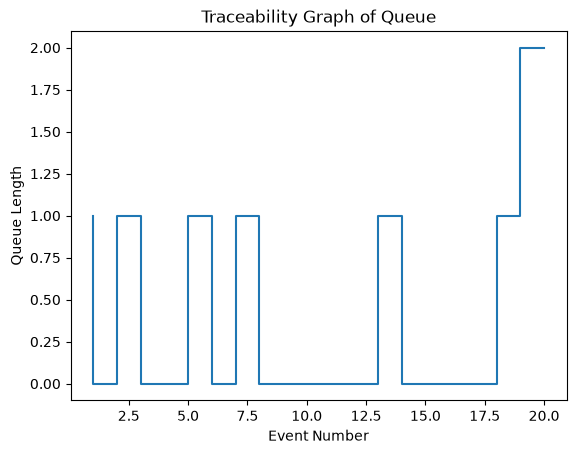

In [2]:
import random
import matplotlib.pyplot as plt

random.seed(10)

clock = 0
queue = 0
queue_history = []

for event in range(1, 21):
    # Random event: arrival or departure
    event_type = random.choice(["Arrival", "Departure"])

    if event_type == "Arrival":
        queue += 1
    else:
        if queue > 0:
            queue -= 1

    clock += random.randint(1, 5)
    queue_history.append(queue)

    # Trace output
    print("Event:", event, "Time:", clock, "Type:", event_type, "   Queue:", queue)

# Graphical view
plt.step(range(1, 21), queue_history)
plt.xlabel("Event Number")
plt.ylabel("Queue Length")
plt.title("Traceability Graph of Queue")
plt.show()

# Lab 15: Confidence Interval Estimation: 
Calculate a 95% confidence interval for the mean system response (e.g., average waiting time) by running multiple independent replications of a simulation model.

#### Confidence interval হলো এমন একটি range, যার মধ্যে true mean থাকার সম্ভাবনা বেশি।

Mean interarrival time from data = 2.05
Mean service time from data = 1.5

Simulation Results
Mean waiting time = 3.5895976315888927
95% Confidence Interval = (np.float64(2.4182651831507), np.float64(4.7609300800270855))


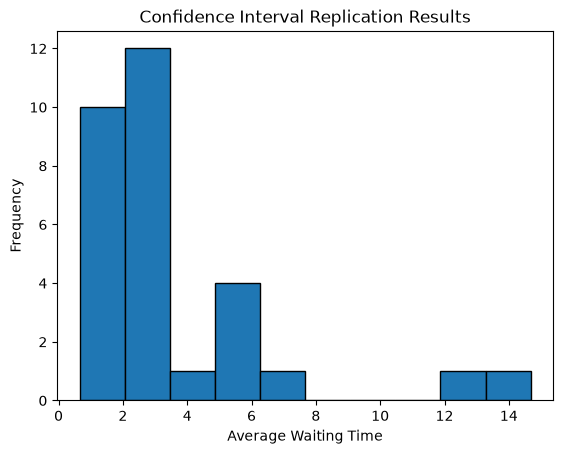

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Same random result পাওয়ার জন্য seed
random.seed(10)

# --------------------------------------------------
# Step 1: Sample observed data
# --------------------------------------------------

# Customer interarrival time-এর sample data
interarrival_sample_data = [1.8, 2.1, 2.4, 1.6, 2.0, 2.3, 1.9, 2.2, 1.7, 2.5]

# Customer service time-এর sample data
service_sample_data = [1.2, 1.5, 1.7, 1.3, 1.6, 1.4, 1.8, 1.5, 1.6, 1.4]

# --------------------------------------------------
# Step 2: Mean calculate from data
# --------------------------------------------------

mean_interarrival = sum(interarrival_sample_data) / len(interarrival_sample_data)
mean_service = sum(service_sample_data) / len(service_sample_data)

print("Mean interarrival time from data =", mean_interarrival)
print("Mean service time from data =", mean_service)

# --------------------------------------------------
# Step 3: M/M/1 simulation function
# --------------------------------------------------

def mm1_simulation():
    clock = 0
    server_free = 0
    delays = []

    for i in range(100):

        # Data থেকে পাওয়া mean ব্যবহার করে interarrival time generate
        interarrival = random.expovariate(1 / mean_interarrival)

        # Data থেকে পাওয়া mean ব্যবহার করে service time generate
        service = random.expovariate(1 / mean_service)

        # Customer arrival time
        arrival = clock + interarrival
        clock = arrival

        # Server free থাকলে immediately service start হবে
        # Server busy থাকলে customer wait করবে
        start = max(arrival, server_free)

        # Waiting time
        delay = start - arrival
        delays.append(delay)

        # Server next free time
        server_free = start + service

    # একবার simulation run করে average waiting time return
    return np.mean(delays)

# --------------------------------------------------
# Step 4: Multiple replications
# --------------------------------------------------

replications = 30
means = []

for i in range(replications):
    result = mm1_simulation()
    means.append(result)

# --------------------------------------------------
# Step 5: Confidence interval calculation
# --------------------------------------------------

mean_value = np.mean(means)
se = stats.sem(means)

ci = stats.t.interval(
    confidence=0.95,
    df=replications - 1,
    loc=mean_value,
    scale=se
)

print("\nSimulation Results")
print("Mean waiting time =", mean_value)
print("95% Confidence Interval =", ci)

# --------------------------------------------------
# Graphical view
# --------------------------------------------------

plt.hist(means, bins=10, edgecolor="black")
plt.xlabel("Average Waiting Time")
plt.ylabel("Frequency")
plt.title("Confidence Interval Replication Results")
plt.show()

# Lab 16: Steady-State Analysis: 
Analyze the warm-up period of a non-terminating simulation (like a continuous manufacturing line) and calculate the steady-state mean time.

Steady-state mean: 51.68792632442412


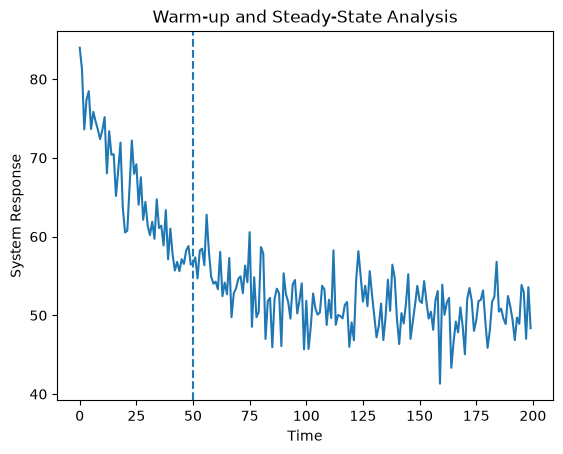

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

time = 200
data = []

for t in range(time):
    # First part unstable, later steady
    value = 50 + 30 * np.exp(-0.03 * t) + np.random.normal(0, 3)
    data.append(value)

warmup = 50
steady_state_data = data[warmup:]

print("Steady-state mean:", np.mean(steady_state_data))

# Graphical view
plt.plot(data)
plt.axvline(warmup, linestyle="--")
plt.xlabel("Time")
plt.ylabel("System Response")
plt.title("Warm-up and Steady-State Analysis")
plt.show()

# Lab 17: Bank ATM System Simulation: 
Model an ATM vestibule where customers arrive at random, use one of several machines, and leave. Calculate the maximum queue lengths.

Mean interarrival time from data = 2.04
Mean ATM service time from data = 3.04

Simulation Results
Maximum queue length = 3
Average waiting time = 0.13648033555689373


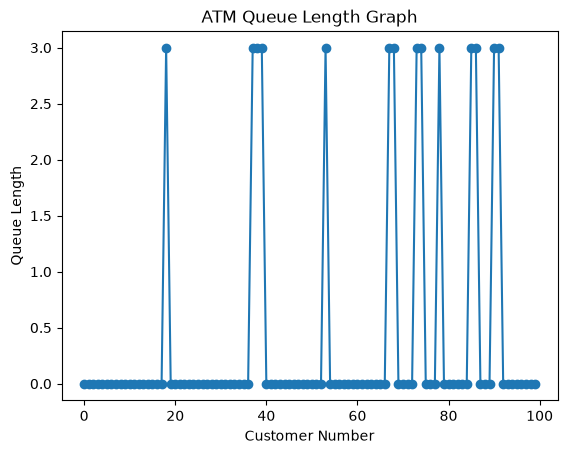

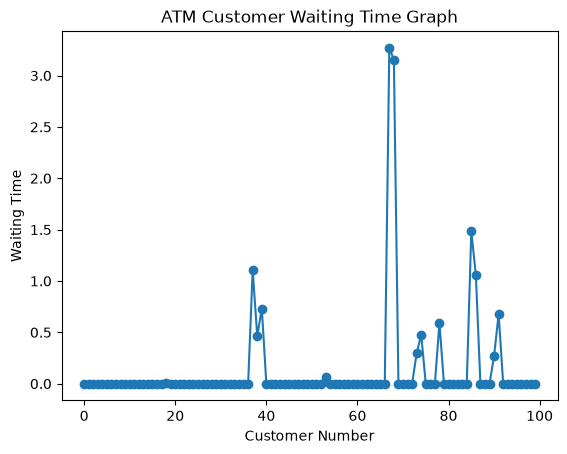

In [5]:
import random
import matplotlib.pyplot as plt

# Same random result পাওয়ার জন্য seed
random.seed(10)

# --------------------------------------------------
# Step 1: Sample observed data
# --------------------------------------------------

# ATM customer interarrival time-এর sample data
interarrival_sample_data = [1.5, 2.0, 2.3, 1.8, 2.2, 1.7, 2.5, 1.9, 2.1, 2.4]

# ATM service time-এর sample data
service_sample_data = [2.5, 3.0, 3.5, 2.8, 3.2, 2.9, 3.4, 3.1, 3.3, 2.7]

# --------------------------------------------------
# Step 2: Mean calculate from data
# --------------------------------------------------

mean_interarrival = sum(interarrival_sample_data) / len(interarrival_sample_data)
mean_service = sum(service_sample_data) / len(service_sample_data)

print("Mean interarrival time from data =", mean_interarrival)
print("Mean ATM service time from data =", mean_service)

# --------------------------------------------------
# Step 3: Simulation inputs
# --------------------------------------------------

customers = 100
num_atm = 3

# প্রতিটি ATM কখন free হবে সেটা রাখবে
atm_free_time = [0] * num_atm

clock = 0
queue_lengths = []
waiting_times = []

# --------------------------------------------------
# Step 4: ATM simulation
# --------------------------------------------------

for i in range(customers):

    # Data থেকে পাওয়া mean ব্যবহার করে customer arrival generate
    interarrival = random.expovariate(1 / mean_interarrival)

    # Data থেকে পাওয়া mean ব্যবহার করে service time generate
    service_time = random.expovariate(1 / mean_service)

    # Customer arrival time
    arrival = clock + interarrival
    clock = arrival

    # সবচেয়ে আগে free হবে এমন ATM খুঁজে বের করা
    atm_index = atm_free_time.index(min(atm_free_time))

    # যদি selected ATM arrival time-এর পর free হয়, তাহলে customer wait করবে
    if atm_free_time[atm_index] > arrival:
        start = atm_free_time[atm_index]
        waiting_time = start - arrival

        # arrival time-এ কয়টা ATM busy ছিল
        queue_length = sum(1 for t in atm_free_time if t > arrival)

    # যদি ATM free থাকে, customer wait করবে না
    else:
        start = arrival
        waiting_time = 0
        queue_length = 0

    # selected ATM কখন free হবে update
    atm_free_time[atm_index] = start + service_time

    # data save
    queue_lengths.append(queue_length)
    waiting_times.append(waiting_time)

# --------------------------------------------------
# Step 5: Final results
# --------------------------------------------------

maximum_queue_length = max(queue_lengths)
average_waiting_time = sum(waiting_times) / len(waiting_times)

print("\nSimulation Results")
print("Maximum queue length =", maximum_queue_length)
print("Average waiting time =", average_waiting_time)

# --------------------------------------------------
# Graph 1: Queue length
# --------------------------------------------------

plt.plot(queue_lengths, marker="o")
plt.xlabel("Customer Number")
plt.ylabel("Queue Length")
plt.title("ATM Queue Length Graph")
plt.show()

# --------------------------------------------------
# Graph 2: Waiting time
# --------------------------------------------------

plt.plot(waiting_times, marker="o")
plt.xlabel("Customer Number")
plt.ylabel("Waiting Time")
plt.title("ATM Customer Waiting Time Graph")
plt.show()

# Lab 18: Fast-Food Drive-Thru Model: 
Simulate a drive-thru process (order, pay, pick up) to identify the system's operational bottlenecks. 

##### Drive-thru process-এ সাধারণত ৩টি stage থাকে:

* Order
* Pay
* Pick up

##### Simulation করে বের করতে হবে কোন stage সবচেয়ে বেশি সময় নিচ্ছে।
##### যে stage সবচেয়ে বেশি সময় নেয়, সেটাই system-এর bottleneck।

Mean order time from data = 3.04
Mean pay time from data = 2.04
Mean pickup time from data = 4.17

Simulation Results
Average order time: 3.6140469886867392
Average pay time: 2.0089832380446255
Average pickup time: 3.977624064206456
Bottleneck stage = Pickup


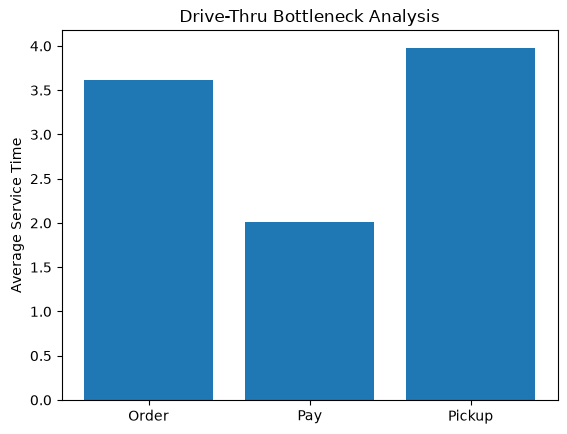

In [6]:
import random
import matplotlib.pyplot as plt

# Same random result পাওয়ার জন্য seed
random.seed(10)

# --------------------------------------------------
# Step 1: Sample observed data
# --------------------------------------------------

# কিছু observed order time data
order_sample_data = [2.5, 3.0, 3.2, 2.8, 3.5, 2.9, 3.1, 3.4, 2.7, 3.3]

# কিছু observed pay time data
pay_sample_data = [1.5, 2.0, 2.2, 1.8, 2.5, 1.9, 2.1, 2.3, 1.7, 2.4]

# কিছু observed pickup time data
pickup_sample_data = [3.5, 4.0, 4.5, 3.8, 4.2, 4.7, 3.9, 4.1, 4.4, 4.6]

# --------------------------------------------------
# Step 2: Mean service time calculate
# --------------------------------------------------

mean_order_time = sum(order_sample_data) / len(order_sample_data)
mean_pay_time = sum(pay_sample_data) / len(pay_sample_data)
mean_pickup_time = sum(pickup_sample_data) / len(pickup_sample_data)

print("Mean order time from data =", mean_order_time)
print("Mean pay time from data =", mean_pay_time)
print("Mean pickup time from data =", mean_pickup_time)

# --------------------------------------------------
# Step 3: Drive-thru simulation
# --------------------------------------------------

cars = 100

order_times = []
pay_times = []
pickup_times = []

for car in range(cars):

    # Sample data থেকে পাওয়া mean ব্যবহার করে random service time generate
    order = random.expovariate(1 / mean_order_time)
    pay = random.expovariate(1 / mean_pay_time)
    pickup = random.expovariate(1 / mean_pickup_time)

    order_times.append(order)
    pay_times.append(pay)
    pickup_times.append(pickup)

# --------------------------------------------------
# Step 4: Simulation output mean
# --------------------------------------------------

avg_order = sum(order_times) / cars
avg_pay = sum(pay_times) / cars
avg_pickup = sum(pickup_times) / cars

print("\nSimulation Results")
print("Average order time:", avg_order)
print("Average pay time:", avg_pay)
print("Average pickup time:", avg_pickup)

# --------------------------------------------------
# Step 5: Bottleneck identification
# --------------------------------------------------

stage_names = ["Order", "Pay", "Pickup"]
average_times = [avg_order, avg_pay, avg_pickup]

max_time = max(average_times)
bottleneck_stage = stage_names[average_times.index(max_time)]

print("Bottleneck stage =", bottleneck_stage)

# --------------------------------------------------
# Graphical view
# --------------------------------------------------

plt.bar(stage_names, average_times)
plt.ylabel("Average Service Time")
plt.title("Drive-Thru Bottleneck Analysis")
plt.show()

# Lab 19: Emergency Room (ER) Patient Flow: 
Simulate the triage, treatment, and discharge of patients in an ER to minimize waiting times and allocate resources.

Mean triage time from data = 5.04
Mean treatment time from data = 20.2
Mean discharge time from data = 8.040000000000001

Simulation Results
Average triage time = 5.991709481243805
Average treatment time = 19.892873239461487
Average discharge time = 7.669088123793744
Average total patient time = 33.55367084449904
Bottleneck stage = Treatment


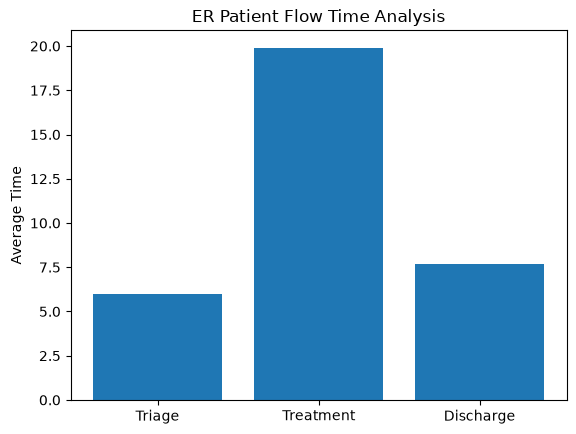

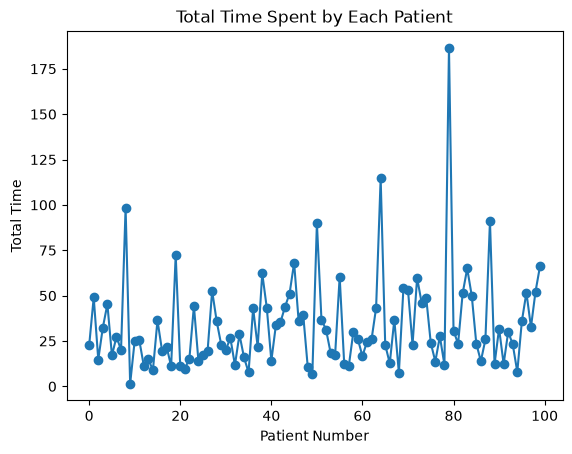

In [7]:
import random
import matplotlib.pyplot as plt

# Same random result পাওয়ার জন্য seed
random.seed(10)

# --------------------------------------------------
# Step 1: Sample observed data
# --------------------------------------------------

# Triage time sample data
triage_sample_data = [4.5, 5.0, 5.5, 4.8, 5.2, 4.7, 5.3, 5.1, 4.9, 5.4]

# Treatment time sample data
treatment_sample_data = [18, 20, 22, 19, 21, 23, 17, 20, 24, 18]

# Discharge time sample data
discharge_sample_data = [7.5, 8.0, 8.5, 7.8, 8.2, 7.7, 8.3, 8.1, 7.9, 8.4]

# --------------------------------------------------
# Step 2: Mean calculate from sample data
# --------------------------------------------------

mean_triage_time = sum(triage_sample_data) / len(triage_sample_data)
mean_treatment_time = sum(treatment_sample_data) / len(treatment_sample_data)
mean_discharge_time = sum(discharge_sample_data) / len(discharge_sample_data)

print("Mean triage time from data =", mean_triage_time)
print("Mean treatment time from data =", mean_treatment_time)
print("Mean discharge time from data =", mean_discharge_time)

# --------------------------------------------------
# Step 3: ER patient flow simulation
# --------------------------------------------------

patients = 100

triage_times = []
treatment_times = []
discharge_times = []
total_times = []

for patient in range(patients):

    # Sample data থেকে পাওয়া mean ব্যবহার করে time generate
    triage = random.expovariate(1 / mean_triage_time)
    treatment = random.expovariate(1 / mean_treatment_time)
    discharge = random.expovariate(1 / mean_discharge_time)

    # Total time for one patient
    total = triage + treatment + discharge

    # Data save
    triage_times.append(triage)
    treatment_times.append(treatment)
    discharge_times.append(discharge)
    total_times.append(total)

# --------------------------------------------------
# Step 4: Simulation result calculation
# --------------------------------------------------

avg_triage = sum(triage_times) / patients
avg_treatment = sum(treatment_times) / patients
avg_discharge = sum(discharge_times) / patients
avg_total_patient_time = sum(total_times) / patients

print("\nSimulation Results")
print("Average triage time =", avg_triage)
print("Average treatment time =", avg_treatment)
print("Average discharge time =", avg_discharge)
print("Average total patient time =", avg_total_patient_time)

# --------------------------------------------------
# Step 5: Bottleneck identification
# --------------------------------------------------

stage_names = ["Triage", "Treatment", "Discharge"]
average_times = [avg_triage, avg_treatment, avg_discharge]

max_time = max(average_times)
bottleneck_stage = stage_names[average_times.index(max_time)]

print("Bottleneck stage =", bottleneck_stage)

# --------------------------------------------------
# Graph 1: Average time by ER stage
# --------------------------------------------------

plt.bar(stage_names, average_times)
plt.ylabel("Average Time")
plt.title("ER Patient Flow Time Analysis")
plt.show()

# --------------------------------------------------
# Graph 2: Total time for each patient
# --------------------------------------------------

plt.plot(total_times, marker="o")
plt.xlabel("Patient Number")
plt.ylabel("Total Time")
plt.title("Total Time Spent by Each Patient")
plt.show()

# Lab 20: Statistical Output Analysis and Precision Estimation for a Drive-Thru Pharmacy Simulation: 
This lab problem evaluates customer flow at an automated drive-thru pharmacy kiosk operating as a terminating simulation system until 50 cars are served. Students are provided with average customer waiting times across five independent replication runs (3.2, 4.3, 5.1, 4.2, and 4.6 minutes) and must apply output data analysis techniques to evaluate the system. The tasks require calculating the overall point estimate (sample mean), computing the sample variance and standard error to measure stochastic variability, and constructing a 95% confidence interval using a Student's t-distribution. Finally, students must determine the total number of simulation replications required to achieve a desired half-width precision of no more than 0.5 minutes, demonstrating how statistical confidence dictates simulation run length.

Replication waiting times = [3.2 4.3 5.1 4.2 4.6]
Number of replications = 5
Sample mean / point estimate = 4.279999999999999
Sample variance = 0.4869999999999997
Sample standard deviation = 0.6978538528947158
Standard error = 0.31208973068654455
t critical value = 2.7764451051977934
Half-width = 0.8665000051471542
95% Confidence Interval = ( 3.4134999948528453 , 5.1465000051471534 )
Required replications for half-width <= 0.5 = 16


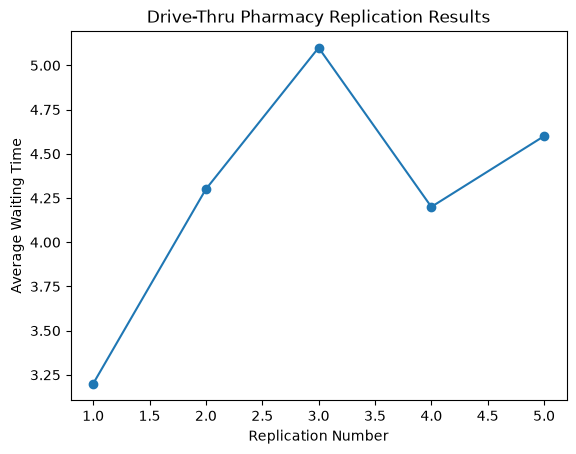

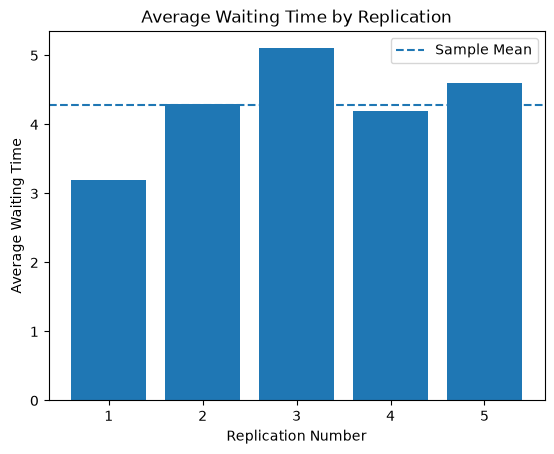

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math

# --------------------------------------------------
# Step 1: Given replication output data
# --------------------------------------------------

# Five independent replication average waiting times
waiting_times = np.array([3.2, 4.3, 5.1, 4.2, 4.6])

# Number of replications
n = len(waiting_times)

# --------------------------------------------------
# Step 2: Point estimate / sample mean
# --------------------------------------------------

sample_mean = np.mean(waiting_times)

# --------------------------------------------------
# Step 3: Sample variance
# --------------------------------------------------

# ddof=1 gives sample variance
sample_variance = np.var(waiting_times, ddof=1)

# Sample standard deviation
sample_sd = np.std(waiting_times, ddof=1)

# --------------------------------------------------
# Step 4: Standard error
# --------------------------------------------------

standard_error = sample_sd / math.sqrt(n)

# --------------------------------------------------
# Step 5: 95% confidence interval using t-distribution
# --------------------------------------------------

confidence_level = 0.95
alpha = 1 - confidence_level
df = n - 1

# t critical value
t_value = stats.t.ppf(1 - alpha / 2, df)

# Half-width
half_width = t_value * standard_error

# Confidence interval
lower_limit = sample_mean - half_width
upper_limit = sample_mean + half_width

# --------------------------------------------------
# Step 6: Required replications for desired precision
# --------------------------------------------------

desired_half_width = 0.5

# Approximate required replication formula
required_replications = math.ceil(
    (t_value * sample_sd / desired_half_width) ** 2
)

# --------------------------------------------------
# Step 7: Output
# --------------------------------------------------

print("Replication waiting times =", waiting_times)
print("Number of replications =", n)
print("Sample mean / point estimate =", sample_mean)
print("Sample variance =", sample_variance)
print("Sample standard deviation =", sample_sd)
print("Standard error =", standard_error)
print("t critical value =", t_value)
print("Half-width =", half_width)
print("95% Confidence Interval = (", lower_limit, ",", upper_limit, ")")
print("Required replications for half-width <= 0.5 =", required_replications)

# --------------------------------------------------
# Graph 1: Replication waiting times
# --------------------------------------------------

plt.plot(range(1, n + 1), waiting_times, marker="o")
plt.xlabel("Replication Number")
plt.ylabel("Average Waiting Time")
plt.title("Drive-Thru Pharmacy Replication Results")
plt.show()

# --------------------------------------------------
# Graph 2: Bar chart of waiting times
# --------------------------------------------------

plt.bar(range(1, n + 1), waiting_times)
plt.axhline(sample_mean, linestyle="--", label="Sample Mean")

plt.xlabel("Replication Number")
plt.ylabel("Average Waiting Time")
plt.title("Average Waiting Time by Replication")
plt.legend()
plt.show()